In [14]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [15]:
ITER1_DIR = Path("../data/v1_csv")
ITER2_DIR = Path("../data/v2_csv")

MODELS_TO_KEEP = ["Qwen 2.5 0.5B", "Qwen 2.5 7B"]

# Since iter2 currently looks like in-domain/"filtered" style results only,
# and iter1 also contains rulebreakers separately, keep this notebook focused
# on the comparable filtered files.
ONLY_FILTERED = True

METRICS = ["precision", "recall", "f1_score"]

SCENARIO_ORDER = [
    "underspecified context",
    "underspecified intent",
    "answer unknown",
    "false premise",
    "subjective",
    "stale",
]

In [16]:
def norm_text(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).lower())


def infer_model(text):
    t = norm_text(text)

    if "qwen2_5_0_5b" in t or "qwen_0_5" in t:
        return "Qwen 2.5 0.5B"

    if "qwen2_5_7b" in t or "qwen_7" in t:
        return "Qwen 2.5 7B"

    return None


def infer_benchmark(path):
    t = norm_text(str(path))

    if "rulebreakers" in t:
        return "rulebreakers"

    # iter1 filtered files explicitly contain "filtered"
    # iter2 v2 files do not, but they are the comparable in-domain files
    if "filtered" in t or "_v2" in t:
        return "filtered"

    return "unknown"


def infer_alpha(path, iteration):
    name = path.stem.lower()

    if iteration == "iter1":
        return 1.0

    match = re.search(r"sweep_(\d+(?:_\d+)?)$", name)
    if match:
        return float(match.group(1).replace("_", "."))

    # Assumption: qwen_0_5_v2.csv and qwen_7_v2.csv correspond to alpha=1.0
    if name.endswith("_v2"):
        return 1.0

    raise ValueError(f"Could not infer alpha from file name: {path.name}")


def load_experiment_folder(root, iteration, only_filtered=True):
    frames = []

    for path in sorted(root.rglob("*.csv")):
        model = infer_model(path)
        if model not in MODELS_TO_KEEP:
            continue

        benchmark = infer_benchmark(path)
        if only_filtered and benchmark != "filtered":
            continue

        df = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]

        expected_cols = {
            "model_name_formatted",
            "scenario_label",
            "dataset_name_formatted",
            "post_training_stage",
            "precision",
            "recall",
            "f1_score",
            "vector_index",
        }
        missing = expected_cols - set(df.columns)
        if missing:
            raise ValueError(
                f"{path.name} is missing columns: {sorted(missing)}"
            )

        for col in ["precision", "recall", "f1_score", "vector_index"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df["model"] = model
        df["iteration"] = iteration
        df["alpha"] = infer_alpha(path, iteration)
        df["alpha_label"] = df["alpha"].map(lambda x: f"{x:.1f}")
        df["benchmark"] = benchmark
        df["normalized_vector"] = iteration == "iter2"
        df["source_file"] = path.name
        df["source_path"] = str(path)

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)

In [17]:
iter1_df = load_experiment_folder(
    ITER1_DIR, iteration="iter1", only_filtered=ONLY_FILTERED
)
iter2_df = load_experiment_folder(
    ITER2_DIR, iteration="iter2", only_filtered=ONLY_FILTERED
)

df = pd.concat([iter1_df, iter2_df], ignore_index=True)

print(f"Loaded rows: {len(df):,}")
display(
    df.groupby(["iteration", "model", "alpha"])
    .agg(
        rows=("f1_score", "size"),
        layers=("vector_index", "nunique"),
        scenarios=("scenario_label", "nunique"),
        datasets=("dataset_name_formatted", "nunique"),
    )
    .reset_index()
    .sort_values(["model", "iteration", "alpha"])
)

display(df.head())

Loaded rows: 5,239


,iteration,model,alpha,rows,layers,scenarios,datasets
0,iter1,Qwen 2.5 0.5B,1.0,434,14,6,31
2,iter2,Qwen 2.5 0.5B,0.5,403,13,6,31
3,iter2,Qwen 2.5 0.5B,1.0,403,13,6,31
4,iter2,Qwen 2.5 0.5B,1.5,403,13,6,31
5,iter2,Qwen 2.5 0.5B,2.0,403,13,6,31
6,iter2,Qwen 2.5 0.5B,3.0,403,13,6,31
1,iter1,Qwen 2.5 7B,1.0,465,15,6,31
7,iter2,Qwen 2.5 7B,0.5,465,15,6,31
8,iter2,Qwen 2.5 7B,1.0,465,15,6,31
9,iter2,Qwen 2.5 7B,1.5,465,15,6,31


,model_name_formatted,scenario_label,dataset_name_formatted,post_training_stage,precision,recall,f1_score,vector_index,model,iteration,alpha,alpha_label,benchmark,normalized_vector,source_file,source_path
0,Qwen2_5_0_5B_Instruct_steered_10,answer unknown,BB/Known unknowns,NaN,0.666667,0.285714,0.400000,10,Qwen 2.5 0.5B,iter1,1.0,1.0,filtered,False,steered_10-23_qwen2_5_0_5B_instruct_keywords_j...,../data/v1_csv/steered_10-23_qwen2_5_0_5B_inst...
1,Qwen2_5_0_5B_Instruct_steered_10,answer unknown,CoCoNot/Unknowns,NaN,1.000000,0.044444,0.085106,10,Qwen 2.5 0.5B,iter1,1.0,1.0,filtered,False,steered_10-23_qwen2_5_0_5B_instruct_keywords_j...,../data/v1_csv/steered_10-23_qwen2_5_0_5B_inst...
2,Qwen2_5_0_5B_Instruct_steered_10,answer unknown,CoCoNot/Unsupported,NaN,0.428571,0.056075,0.099174,10,Qwen 2.5 0.5B,iter1,1.0,1.0,filtered,False,steered_10-23_qwen2_5_0_5B_instruct_keywords_j...,../data/v1_csv/steered_10-23_qwen2_5_0_5B_inst...
3,Qwen2_5_0_5B_Instruct_steered_10,answer unknown,KUQ/Future unknowns,NaN,0.565217,0.096654,0.165079,10,Qwen 2.5 0.5B,iter1,1.0,1.0,filtered,False,steered_10-23_qwen2_5_0_5B_instruct_keywords_j...,../data/v1_csv/steered_10-23_qwen2_5_0_5B_inst...
4,Qwen2_5_0_5B_Instruct_steered_10,answer unknown,KUQ/Unsolved problems,NaN,0.482143,0.159763,0.240000,10,Qwen 2.5 0.5B,iter1,1.0,1.0,filtered,False,steered_10-23_qwen2_5_0_5B_instruct_keywords_j...,../data/v1_csv/steered_10-23_qwen2_5_0_5B_inst...


In [18]:
def aggregate_row_macro(data, group_cols):
    return (
        data.groupby(group_cols, dropna=False)[METRICS]
        .mean()
        .reset_index()
        .rename(
            columns={
                "precision": "precision_row_macro",
                "recall": "recall_row_macro",
                "f1_score": "f1_row_macro",
            }
        )
    )


def aggregate_scenario_macro(data, group_cols):
    scenario_level = (
        data.groupby(group_cols + ["scenario_label"], dropna=False)[METRICS]
        .mean()
        .reset_index()
    )

    return (
        scenario_level.groupby(group_cols, dropna=False)[METRICS]
        .mean()
        .reset_index()
        .rename(
            columns={
                "precision": "precision_scenario_macro",
                "recall": "recall_scenario_macro",
                "f1_score": "f1_scenario_macro",
            }
        )
    )


group_cols = ["iteration", "model", "alpha", "vector_index"]

row_macro = aggregate_row_macro(df, group_cols)
scenario_macro = aggregate_scenario_macro(df, group_cols)

summary = (
    row_macro.merge(scenario_macro, on=group_cols, how="inner")
    .sort_values(["model", "iteration", "alpha", "vector_index"])
    .reset_index(drop=True)
)

display(summary.head(20))

,iteration,model,alpha,vector_index,precision_row_macro,recall_row_macro,f1_row_macro,precision_scenario_macro,recall_scenario_macro,f1_scenario_macro
0,iter1,Qwen 2.5 0.5B,1.0,10,0.560889,0.149578,0.192565,0.597388,0.123380,0.175412
1,iter1,Qwen 2.5 0.5B,1.0,11,0.515969,0.217530,0.257051,0.544943,0.206468,0.258369
2,iter1,Qwen 2.5 0.5B,1.0,12,0.533088,0.226873,0.258364,0.575315,0.205424,0.254117
3,iter1,Qwen 2.5 0.5B,1.0,13,0.539634,0.286655,0.303064,0.585539,0.275981,0.309040
4,iter1,Qwen 2.5 0.5B,1.0,14,0.544449,0.178209,0.222941,0.557775,0.184528,0.242759
5,iter1,Qwen 2.5 0.5B,1.0,15,0.557034,0.154751,0.203162,0.592010,0.164293,0.225179
6,iter1,Qwen 2.5 0.5B,1.0,16,0.587258,0.166815,0.216119,0.607456,0.172185,0.224171
7,iter1,Qwen 2.5 0.5B,1.0,17,0.517182,0.130540,0.182466,0.550022,0.145837,0.205172
8,iter1,Qwen 2.5 0.5B,1.0,18,0.599460,0.121529,0.168803,0.612909,0.121064,0.174988
9,iter1,Qwen 2.5 0.5B,1.0,19,0.550830,0.096045,0.139419,0.573892,0.111298,0.162330


In [19]:
PRIMARY_SCORE = "f1_scenario_macro"


def pick_best_setting(summary_df, filters=None, group_cols=None, score_col=PRIMARY_SCORE):
    temp = summary_df.copy()

    if filters is not None:
        for col, value in filters.items():
            if isinstance(value, (list, tuple, set)):
                temp = temp[temp[col].isin(value)]
            else:
                temp = temp[temp[col] == value]

    if group_cols is None:
        group_cols = ["model"]

    temp = temp.sort_values(
        group_cols + [score_col],
        ascending=[True] * len(group_cols) + [False],
    )

    return temp.groupby(group_cols, as_index=False).first()


iter1_best = pick_best_setting(summary, filters={"iteration": "iter1"})
iter2_alpha1_best = pick_best_setting(
    summary, filters={"iteration": "iter2", "alpha": 1.0}
)
iter2_best_any = pick_best_setting(summary, filters={"iteration": "iter2"})

display(iter1_best)
display(iter2_alpha1_best)
display(iter2_best_any)

,model,iteration,alpha,vector_index,precision_row_macro,recall_row_macro,f1_row_macro,precision_scenario_macro,recall_scenario_macro,f1_scenario_macro
0,Qwen 2.5 0.5B,iter1,1.0,23,0.521735,0.368478,0.398520,0.566780,0.399215,0.431382
1,Qwen 2.5 7B,iter1,1.0,15,0.650981,0.135786,0.169024,0.642207,0.082343,0.116917


,model,iteration,alpha,vector_index,precision_row_macro,recall_row_macro,f1_row_macro,precision_scenario_macro,recall_scenario_macro,f1_scenario_macro
0,Qwen 2.5 0.5B,iter2,1.0,16,0.53848,0.102597,0.150253,0.573572,0.121420,0.181337
1,Qwen 2.5 7B,iter2,1.0,14,0.55990,0.112578,0.141763,0.502143,0.066925,0.095584


,model,iteration,alpha,vector_index,precision_row_macro,recall_row_macro,f1_row_macro,precision_scenario_macro,recall_scenario_macro,f1_scenario_macro
0,Qwen 2.5 0.5B,iter2,3.0,13,0.517673,0.317723,0.321723,0.566969,0.297744,0.320026
1,Qwen 2.5 7B,iter2,3.0,13,0.586755,0.115199,0.145702,0.574467,0.073780,0.106827


In [20]:
iter1_cmp = iter1_best[
    [
        "model",
        "alpha",
        "vector_index",
        "precision_scenario_macro",
        "recall_scenario_macro",
        "f1_scenario_macro",
        "f1_row_macro",
    ]
].rename(
    columns={
        "alpha": "iter1_alpha",
        "vector_index": "iter1_layer",
        "precision_scenario_macro": "iter1_precision",
        "recall_scenario_macro": "iter1_recall",
        "f1_scenario_macro": "iter1_f1",
        "f1_row_macro": "iter1_f1_row_macro",
    }
)

iter2_alpha1_cmp = iter2_alpha1_best[
    [
        "model",
        "alpha",
        "vector_index",
        "precision_scenario_macro",
        "recall_scenario_macro",
        "f1_scenario_macro",
        "f1_row_macro",
    ]
].rename(
    columns={
        "alpha": "iter2_alpha1_alpha",
        "vector_index": "iter2_alpha1_layer",
        "precision_scenario_macro": "iter2_alpha1_precision",
        "recall_scenario_macro": "iter2_alpha1_recall",
        "f1_scenario_macro": "iter2_alpha1_f1",
        "f1_row_macro": "iter2_alpha1_f1_row_macro",
    }
)

iter2_best_cmp = iter2_best_any[
    [
        "model",
        "alpha",
        "vector_index",
        "precision_scenario_macro",
        "recall_scenario_macro",
        "f1_scenario_macro",
        "f1_row_macro",
    ]
].rename(
    columns={
        "alpha": "iter2_best_alpha",
        "vector_index": "iter2_best_layer",
        "precision_scenario_macro": "iter2_best_precision",
        "recall_scenario_macro": "iter2_best_recall",
        "f1_scenario_macro": "iter2_best_f1",
        "f1_row_macro": "iter2_best_f1_row_macro",
    }
)

comparison_table = (
    iter1_cmp.merge(iter2_alpha1_cmp, on="model", how="inner")
    .merge(iter2_best_cmp, on="model", how="inner")
)

comparison_table["delta_iter2_alpha1_vs_iter1"] = (
    comparison_table["iter2_alpha1_f1"] - comparison_table["iter1_f1"]
)
comparison_table["delta_iter2_best_vs_iter1"] = (
    comparison_table["iter2_best_f1"] - comparison_table["iter1_f1"]
)
comparison_table["delta_iter2_best_vs_iter2_alpha1"] = (
    comparison_table["iter2_best_f1"] - comparison_table["iter2_alpha1_f1"]
)

display(
    comparison_table.round(4).style.background_gradient(
        subset=[
            "iter1_f1",
            "iter2_alpha1_f1",
            "iter2_best_f1",
            "delta_iter2_alpha1_vs_iter1",
            "delta_iter2_best_vs_iter1",
            "delta_iter2_best_vs_iter2_alpha1",
        ],
        cmap="YlGn",
    )
)

,model,iter1_alpha,iter1_layer,iter1_precision,iter1_recall,iter1_f1,iter1_f1_row_macro,iter2_alpha1_alpha,iter2_alpha1_layer,iter2_alpha1_precision,iter2_alpha1_recall,iter2_alpha1_f1,iter2_alpha1_f1_row_macro,iter2_best_alpha,iter2_best_layer,iter2_best_precision,iter2_best_recall,iter2_best_f1,iter2_best_f1_row_macro,delta_iter2_alpha1_vs_iter1,delta_iter2_best_vs_iter1,delta_iter2_best_vs_iter2_alpha1
0,Qwen 2.5 0.5B,1.000000,23,0.566800,0.399200,0.431400,0.398500,1.000000,16,0.573600,0.121400,0.181300,0.150300,3.000000,13,0.567000,0.297700,0.320000,0.321700,-0.250000,-0.111400,0.138700
1,Qwen 2.5 7B,1.000000,15,0.642200,0.082300,0.116900,0.169000,1.000000,14,0.502100,0.066900,0.095600,0.141800,3.000000,13,0.574500,0.073800,0.106800,0.145700,-0.021300,-0.010100,0.011200


In [21]:
iter2_ranked = (
    summary[summary["iteration"] == "iter2"]
    .sort_values(["model", PRIMARY_SCORE], ascending=[True, False])
    .reset_index(drop=True)
)

display(
    iter2_ranked[
        [
            "model",
            "alpha",
            "vector_index",
            "precision_scenario_macro",
            "recall_scenario_macro",
            "f1_scenario_macro",
            "f1_row_macro",
        ]
    ]
    .groupby("model", as_index=False)
    .head(15)
)

,model,alpha,vector_index,precision_scenario_macro,recall_scenario_macro,f1_scenario_macro,f1_row_macro
0,Qwen 2.5 0.5B,3.0,13,0.566969,0.297744,0.320026,0.321723
1,Qwen 2.5 0.5B,3.0,11,0.524271,0.245565,0.288714,0.291915
2,Qwen 2.5 0.5B,3.0,12,0.581508,0.243452,0.284505,0.296489
3,Qwen 2.5 0.5B,2.0,13,0.581730,0.219115,0.270894,0.257240
4,Qwen 2.5 0.5B,2.0,11,0.596749,0.189821,0.248674,0.248194
5,Qwen 2.5 0.5B,3.0,16,0.613504,0.167930,0.227917,0.198914
6,Qwen 2.5 0.5B,3.0,14,0.597747,0.169352,0.227338,0.216941
7,Qwen 2.5 0.5B,2.0,12,0.573170,0.169241,0.222321,0.216535
8,Qwen 2.5 0.5B,1.5,13,0.571087,0.170905,0.220282,0.221648
9,Qwen 2.5 0.5B,1.5,11,0.554462,0.151757,0.207424,0.200648


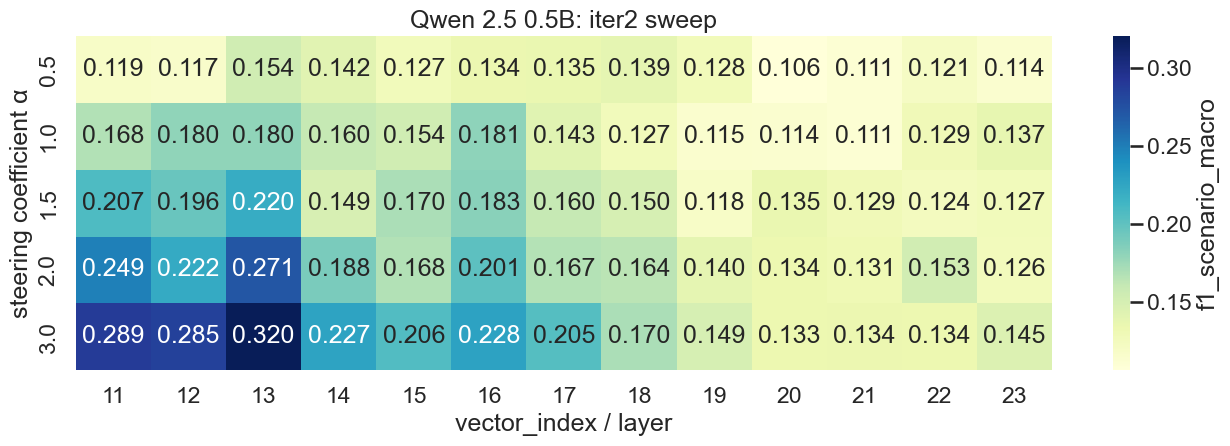

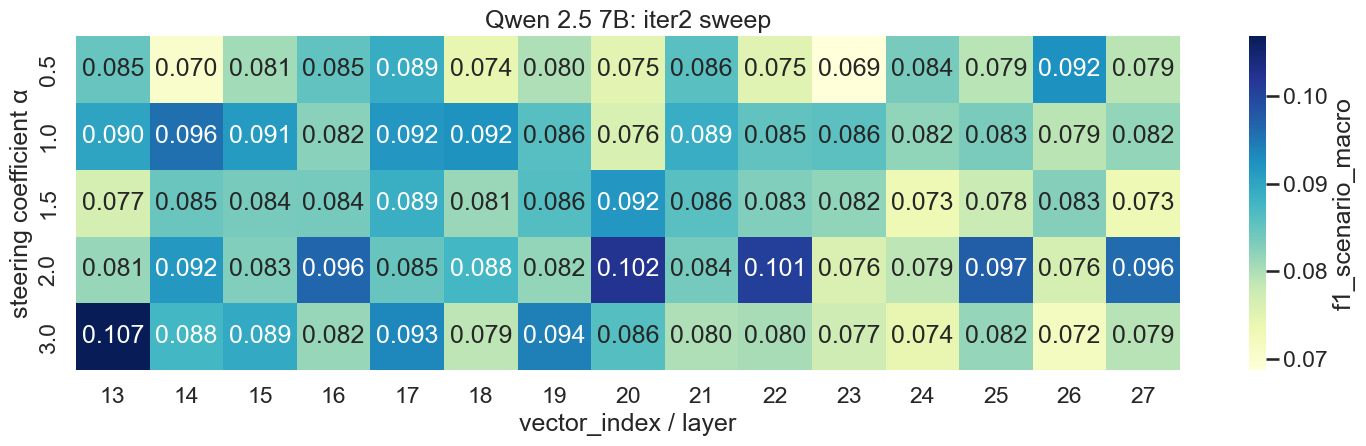

In [22]:
def plot_iter2_heatmap(summary_df, model, value_col="f1_scenario_macro"):
    plot_df = summary_df[
        (summary_df["iteration"] == "iter2")
        & (summary_df["model"] == model)
    ].copy()

    heat = plot_df.pivot(
        index="alpha",
        columns="vector_index",
        values=value_col,
    ).sort_index().sort_index(axis=1)

    plt.figure(figsize=(max(10, 0.8 * heat.shape[1] + 3), 4.8))
    ax = sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": value_col},
    )
    ax.set_title(f"{model}: iter2 sweep")
    ax.set_xlabel("vector_index / layer")
    ax.set_ylabel("steering coefficient α")
    plt.tight_layout()
    plt.show()


for model in MODELS_TO_KEEP:
    plot_iter2_heatmap(summary, model)

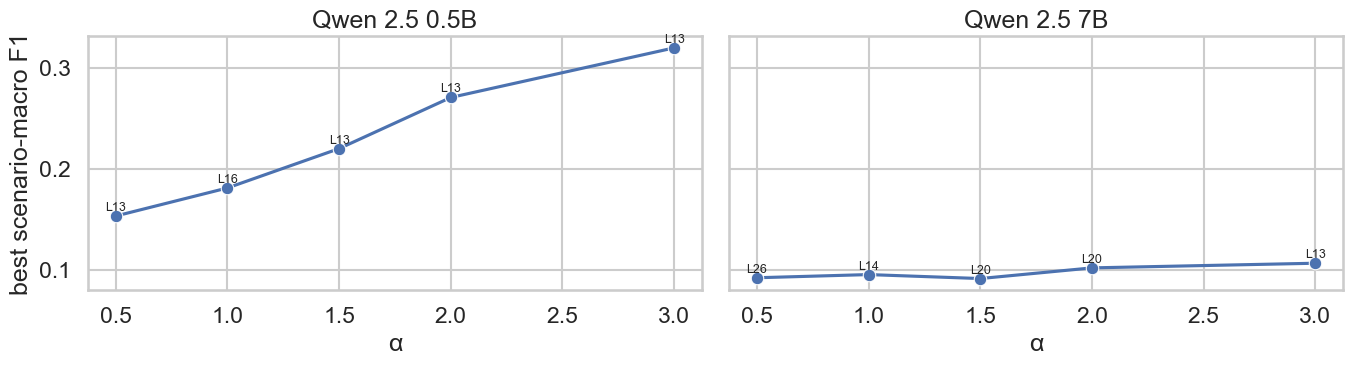

In [23]:
best_layer_per_alpha = pick_best_setting(
    summary,
    filters={"iteration": "iter2"},
    group_cols=["model", "alpha"],
)

fig, axes = plt.subplots(1, len(MODELS_TO_KEEP), figsize=(14, 4), sharey=True)

for ax, model in zip(axes, MODELS_TO_KEEP):
    sub = best_layer_per_alpha[
        best_layer_per_alpha["model"] == model
    ].sort_values("alpha")

    sns.lineplot(
        data=sub,
        x="alpha",
        y="f1_scenario_macro",
        marker="o",
        ax=ax,
    )

    for _, row in sub.iterrows():
        ax.text(
            row["alpha"],
            row["f1_scenario_macro"] + 0.002,
            f"L{int(row['vector_index'])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(model)
    ax.set_xlabel("α")
    ax.set_ylabel("best scenario-macro F1")

plt.tight_layout()
plt.show()

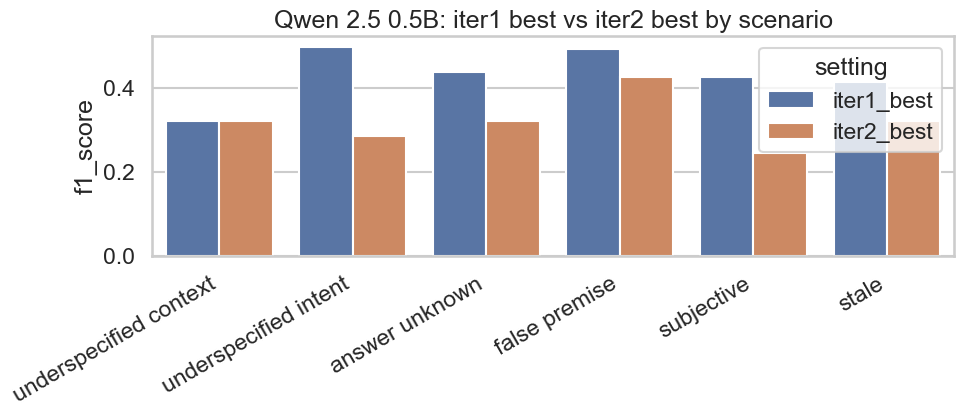

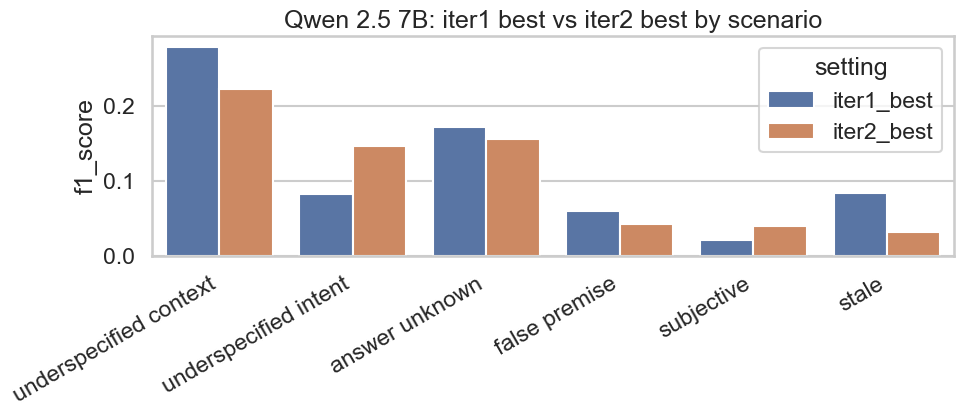

In [24]:
def scenario_profile(raw_df, model, iteration, alpha, layer):
    sub = raw_df[
        (raw_df["model"] == model)
        & (raw_df["iteration"] == iteration)
        & (raw_df["alpha"] == alpha)
        & (raw_df["vector_index"] == layer)
    ].copy()

    out = (
        sub.groupby("scenario_label")[METRICS]
        .mean()
        .reset_index()
    )

    out["scenario_label"] = pd.Categorical(
        out["scenario_label"],
        categories=SCENARIO_ORDER,
        ordered=True,
    )

    return out.sort_values("scenario_label")


def plot_best_old_vs_new_by_scenario(raw_df, comparison_row, metric="f1_score"):
    model = comparison_row["model"]

    old_prof = scenario_profile(
        raw_df,
        model=model,
        iteration="iter1",
        alpha=comparison_row["iter1_alpha"],
        layer=comparison_row["iter1_layer"],
    )[["scenario_label", metric]].rename(columns={metric: "iter1_best"})

    new_prof = scenario_profile(
        raw_df,
        model=model,
        iteration="iter2",
        alpha=comparison_row["iter2_best_alpha"],
        layer=comparison_row["iter2_best_layer"],
    )[["scenario_label", metric]].rename(columns={metric: "iter2_best"})

    plot_df = old_prof.merge(new_prof, on="scenario_label", how="outer")
    plot_df = plot_df.melt(
        id_vars="scenario_label",
        var_name="setting",
        value_name=metric,
    )

    plt.figure(figsize=(10, 4.5))
    sns.barplot(
        data=plot_df,
        x="scenario_label",
        y=metric,
        hue="setting",
    )
    plt.title(f"{model}: iter1 best vs iter2 best by scenario")
    plt.xlabel("")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


for _, row in comparison_table.iterrows():
    plot_best_old_vs_new_by_scenario(df, row, metric="f1_score")

In [25]:
OUT_DIR = Path("./analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)

summary.to_csv(OUT_DIR / "summary_all_settings.csv", index=False)
comparison_table.to_csv(OUT_DIR / "iter1_vs_iter2_comparison.csv", index=False)
iter2_ranked.to_csv(OUT_DIR / "iter2_ranked_settings.csv", index=False)
best_layer_per_alpha.to_csv(
    OUT_DIR / "iter2_best_layer_per_alpha.csv",
    index=False,
)

print(f"Saved outputs to: {OUT_DIR.resolve()}")

Saved outputs to: /Users/artem/Desktop/study/cs/y4/turing/AbstentionBench/notebooks/analysis_outputs
